In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download

In [105]:
OHCO = ['book_title', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]

In [106]:
BOW=pd.read_csv("BOW.csv")

In [107]:
BOW

,book_title,term_str,n,tfidf
0,A Tale of Two Cities 1,a,422,0.000000
1,A Tale of Two Cities 1,abandoned,2,0.000015
2,A Tale of Two Cities 1,abiding,1,0.000077
3,A Tale of Two Cities 1,ability,1,0.000025
4,A Tale of Two Cities 1,about,23,0.000000
...,...,...,...,...
233583,The Old Curiosity Shop,youve,18,0.000011
233584,The Old Curiosity Shop,zambullo,1,0.000021
233585,The Old Curiosity Shop,zeal,2,0.000009
233586,The Old Curiosity Shop,zenith,1,0.000008


In [108]:
SALEX = pd.read_csv("salex_nrc.csv").set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [109]:
LIB=pd.read_csv("Corpus_Lib.csv")
TOKENS=pd.read_csv("Corpus_Tokens.csv").set_index(OHCO)
VOCAB=pd.read_csv("Corpus_Vocab.csv")

In [110]:
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

In [111]:
OHCO = ['book_title', 'chap_num', 'para_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    PARAS = OHCO[:3],
    CHAPS = OHCO[:2],
    BOOKS = OHCO[:1])

In [112]:
bag=OHCO[:1]

In [113]:
VOCAB_SA = VOCAB.join(SALEX, on='term_str', how='right').set_index('term_str')

In [114]:
BOW_SENT=BOW_SA = BOW.merge(
    VOCAB_SA,
    left_on='term_str',
    right_index=True,
    how='left'
)

In [115]:
BOW_SENT

,book_title,term_str,n_x,tfidf,term_id,n_y,p,i,max_pos_group,max_pos,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
0,A Tale of Two Cities 1,a,422,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A Tale of Two Cities 1,abandoned,2,0.000015,3246.0,93.0,0.000024,15.340029,VB,VBN,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.0
2,A Tale of Two Cities 1,abiding,1,0.000077,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A Tale of Two Cities 1,ability,1,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A Tale of Two Cities 1,about,23,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233583,The Old Curiosity Shop,youve,18,0.000011,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233584,The Old Curiosity Shop,zambullo,1,0.000021,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233585,The Old Curiosity Shop,zeal,2,0.000009,7092.0,31.0,0.000008,16.924992,NN,NN,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
233586,The Old Curiosity Shop,zenith,1,0.000008,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
DOC_SENT = BOW_SENT.groupby(OHCO[:1])[emo_cols].mean()

In [117]:
DOC_SENT

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
book_title,,,,,,,,,
A Tale of Two Cities 1,0.262411,0.224586,0.217494,0.378251,0.257683,0.338061,0.160757,0.304965,-0.122931
A Tale of Two Cities 2,0.308664,0.215704,0.224729,0.378159,0.231047,0.308664,0.129964,0.308664,-0.154332
A Tale of Two Cities 3,0.293915,0.231917,0.229621,0.393800,0.246843,0.329506,0.148106,0.308840,-0.159587
Barnaby Rudge,0.318335,0.220472,0.229471,0.365579,0.236783,0.307087,0.136670,0.282902,-0.197413
Bleak House,0.299791,0.217414,0.241919,0.350886,0.233055,0.299270,0.130344,0.299270,-0.168926
David Copperfield,0.306611,0.213951,0.244664,0.360750,0.231650,0.320666,0.131702,0.285789,-0.194690
Dombey and Son,0.303376,0.218471,0.233366,0.353029,0.237835,0.309335,0.130089,0.295432,-0.173784
Great Expectations,0.299870,0.215674,0.244171,0.356218,0.229922,0.311528,0.122409,0.298575,-0.194301
Hard Times 1,0.253814,0.249653,0.219140,0.324549,0.263523,0.313454,0.147018,0.327323,-0.106796


In [118]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left') #.fillna(0)

In [119]:
SENT_SA = TOKENS_SA.groupby(SENTS)[emo_cols].mean()

In [120]:
BOOK_SA = TOKENS_SA.fillna(0).groupby('book_title')[emo_cols].mean()

In [121]:
analyser = SentimentIntensityAnalyzer()

In [122]:
SENT_SA['sent_str'] = TOKENS_SA.groupby(SENTS)[['term_str']].apply(lambda x: ' '.join(map(str, x.term_str)))
SENT_VADER = SENT_SA.sent_str.apply(analyser.polarity_scores).apply(pd.Series)

In [123]:
SENT_SA['sent_str'] = TOKENS_SA.groupby(SENTS)[['term_str']].apply(lambda x: ' '.join(map(str, x.term_str)))
SENT_VADER = SENT_SA.sent_str.apply(analyser.polarity_scores).apply(pd.Series)
SENT_VADER.head()

neg    neu    pos  \
book_title             chap_num para_num sent_num                        
A Tale of Two Cities 1 1        0        0         0.000  1.000  0.000   
                                1        0         0.109  0.755  0.136   
                                2        0         0.000  1.000  0.000   
                                         1         0.000  0.867  0.133   
                                         2         0.000  1.000  0.000   

                                                   compound  
book_title             chap_num para_num sent_num            
A Tale of Two Cities 1 1        0        0           0.0000  
                                1        0           0.5965  
                                2        0           0.0000  
                                         1           0.3182  
                                         2           0.0000

In [124]:
def plot_book_sa(book_id, wf = 5):
    # wf: window size factor
    df = SENT_VADER.loc[book_id]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle(book_id.upper(), y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

In [125]:
def plot_books_sa(book_ids, wf=5):
    fig, axes = plt.subplots(4, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle("Sentiment Comparison Across Books", y=1, fontsize=20)

    sentiments = ['pos', 'neg', 'neu', 'compound']

    for book_id in book_ids:
        df = SENT_VADER.loc[book_id].copy()

  
        w = int(df.shape[0] / wf)
        df_roll = df[sentiments].rolling(w).mean()
        x = np.linspace(0, 1, len(df_roll))
        for i, sent in enumerate(sentiments):
            axes[i].plot(x, df_roll[sent], label=book_id)
            
    for i, sent in enumerate(sentiments):
        axes[i].set_title(sent.upper())
        axes[i].legend(loc='upper right')

    axes[-1].set_xlabel("Narrative Progress (Normalized)")

    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

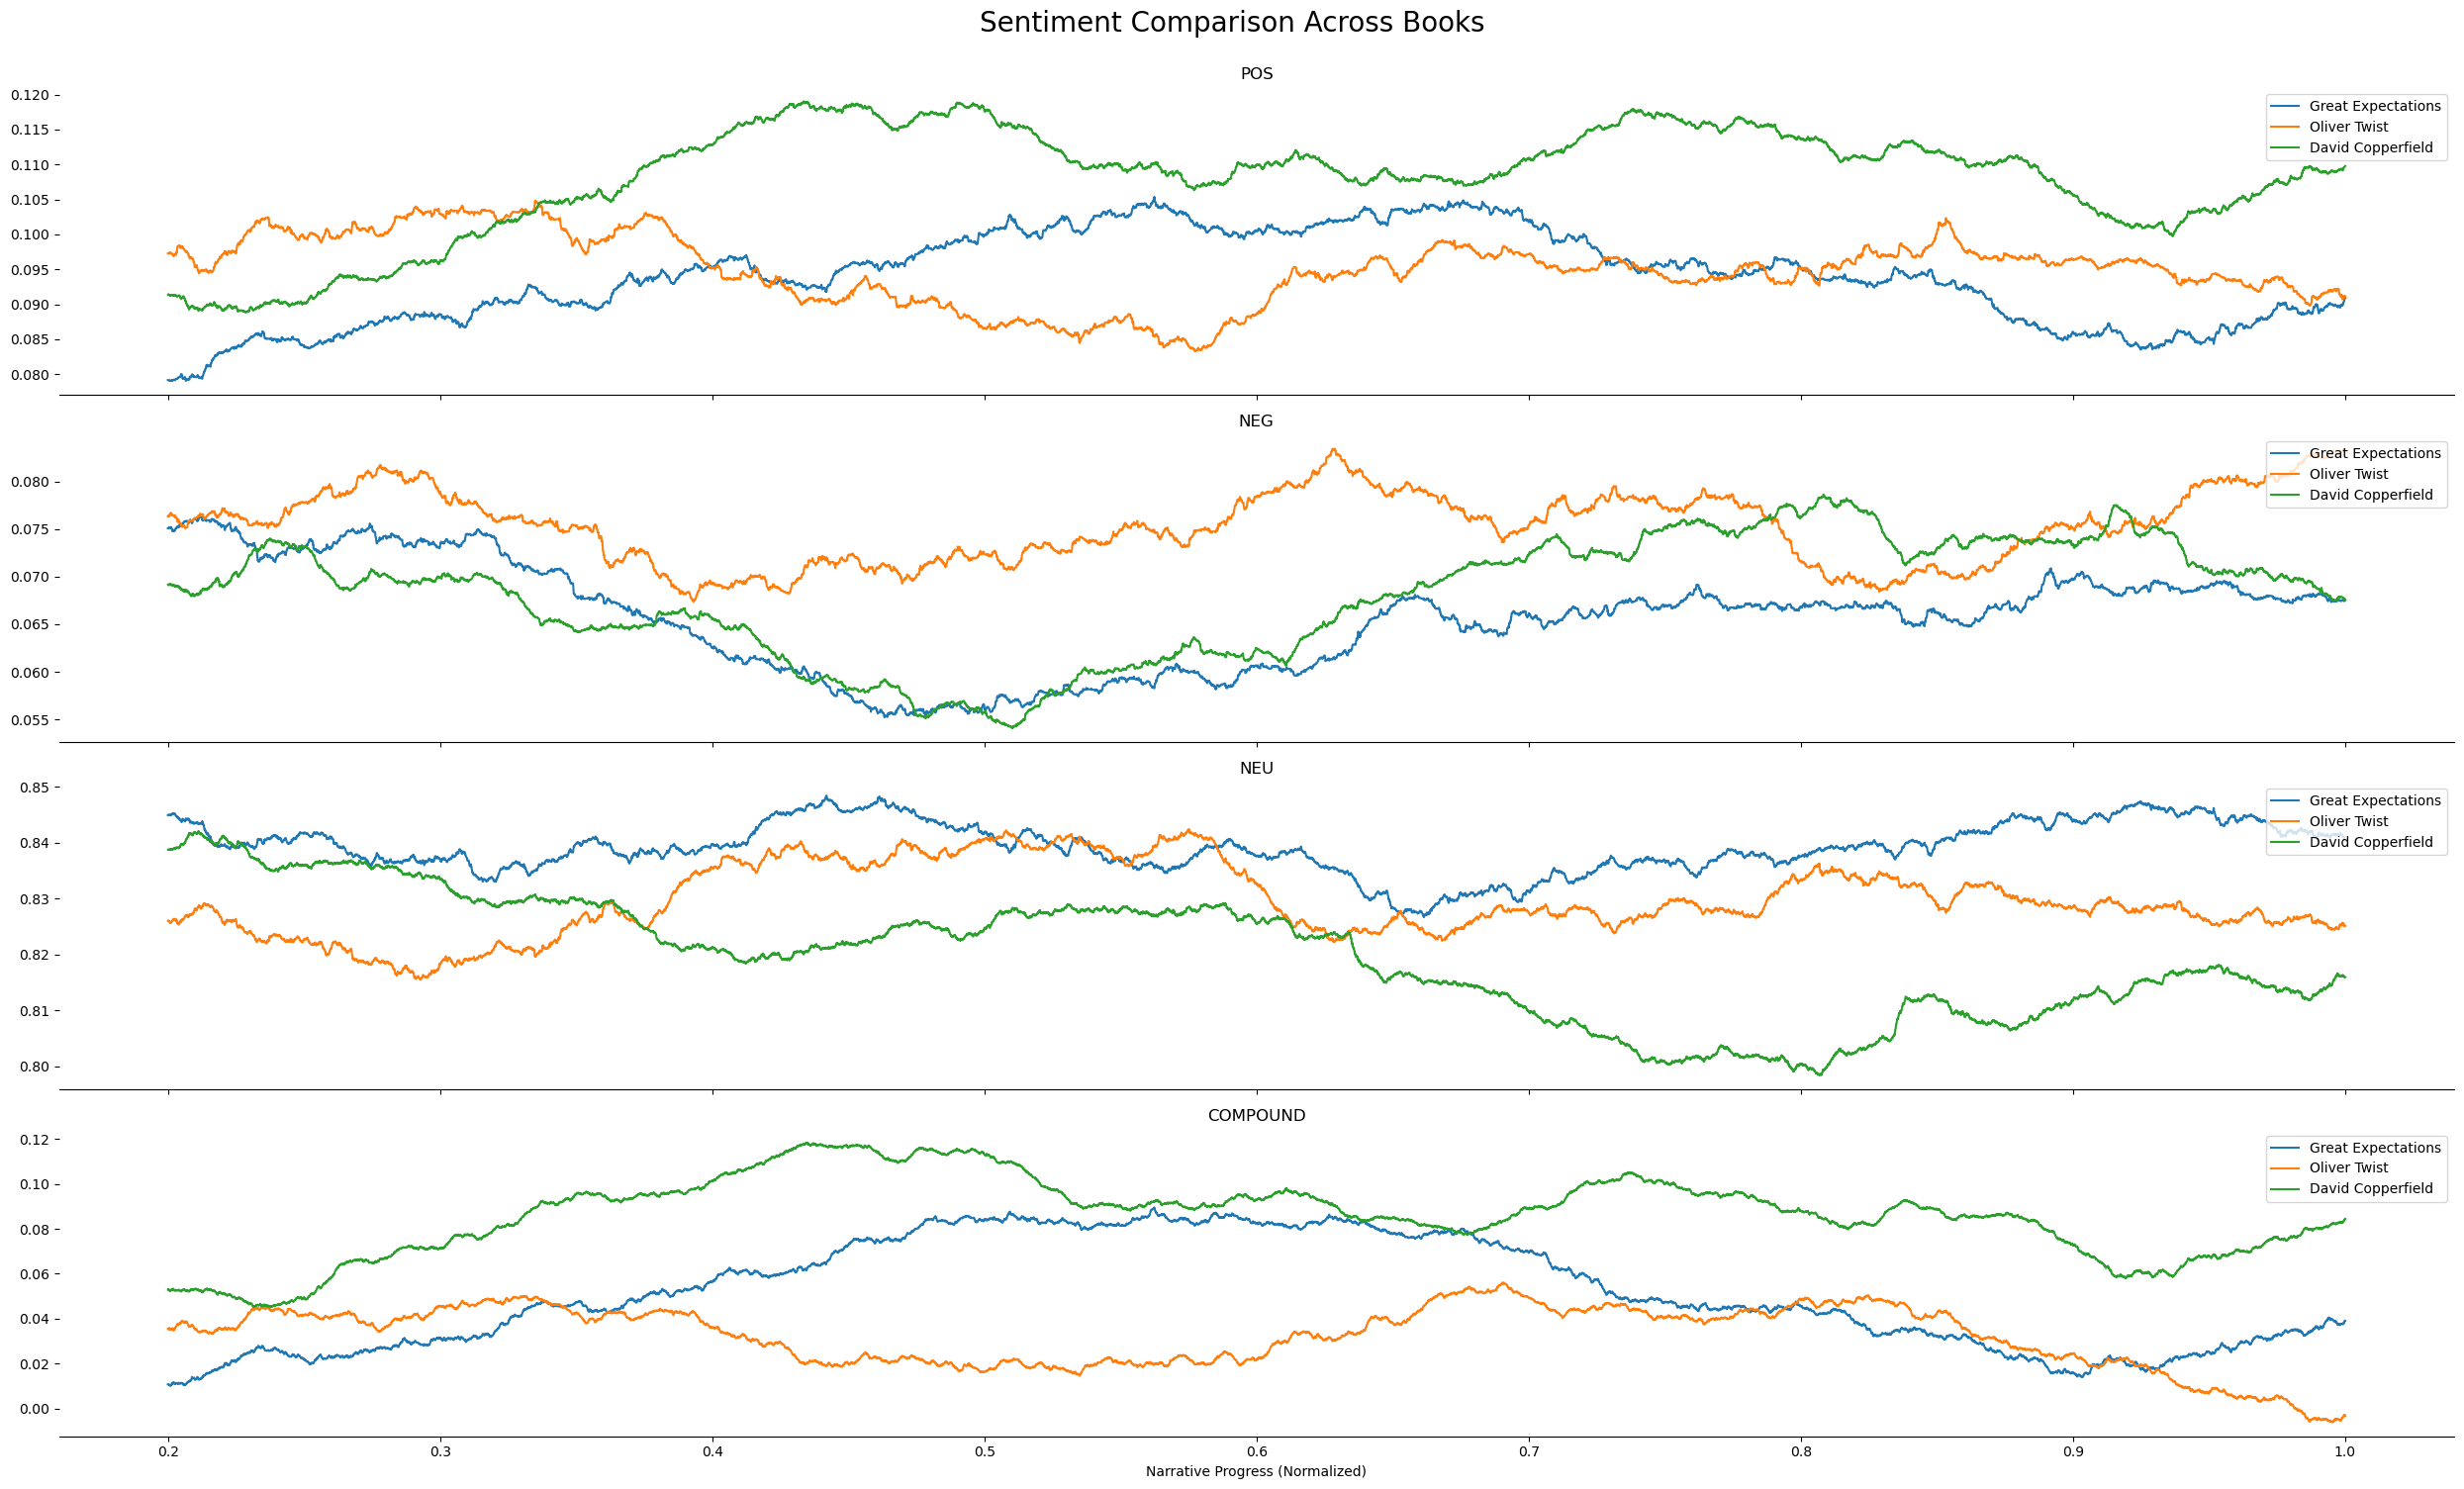

In [126]:
plot_books_sa(["Great Expectations","Oliver Twist","David Copperfield"], wf=5)

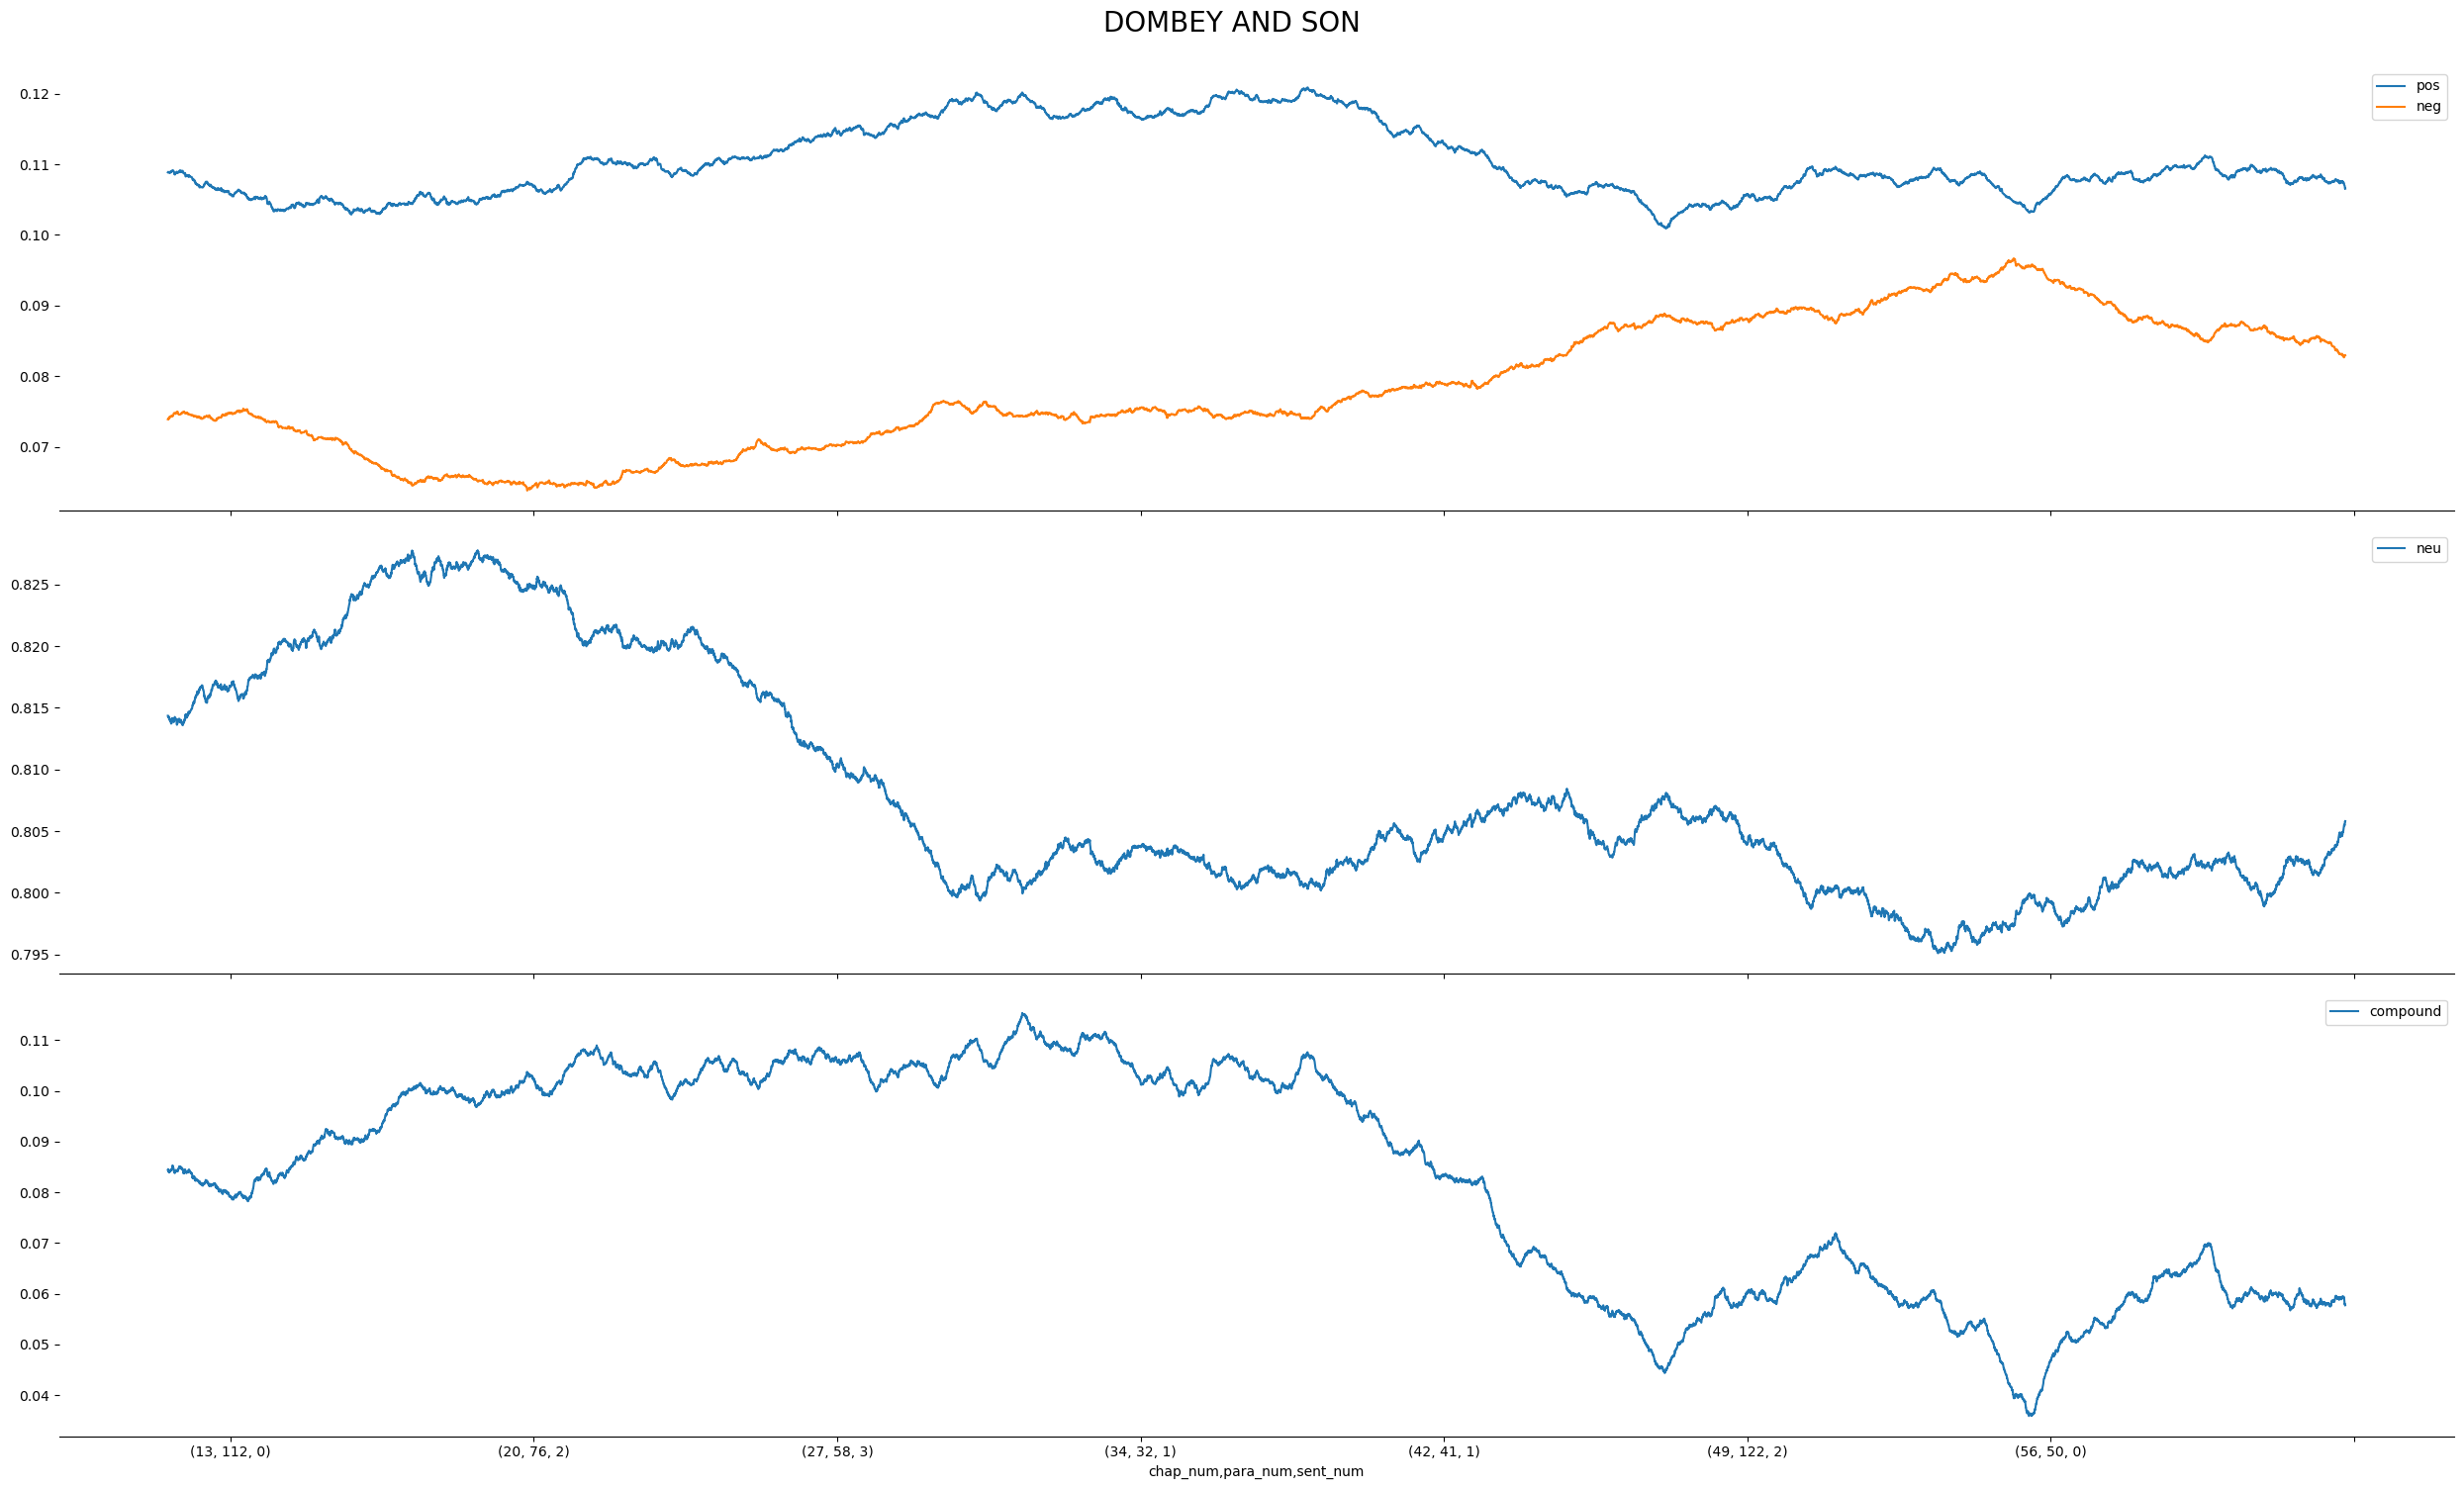

In [127]:
plot_book_sa('Dombey and Son')

## RIFF 2

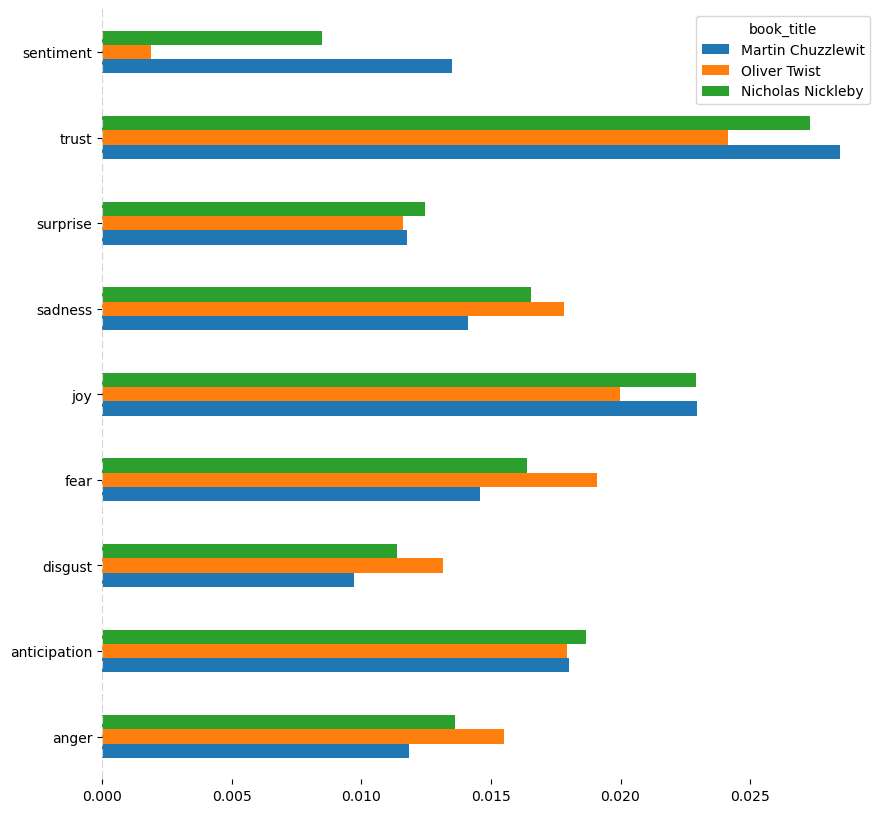

In [128]:
ax = BOOK_SA.loc[['Martin Chuzzlewit',"Oliver Twist","Nicholas Nickleby"]].T.plot.barh(figsize=(10,10))
ax.axvline(0, c='lightgray', ls='--')
sns.despine(left=True, bottom=True)
plt.show()

In [129]:
VOCAB_SA.to_csv("VOCAB_SENT.csv")
BOW_SENT.to_csv("BOW_SENT.csv")
DOC_SENT.to_csv("DOC_SENT.csv")